In [78]:
#importacion de librerias

import pandas as pd           # Apertura y preprocesamiento del dataset
import numpy as np            # Operaciones vectoriales y matriciales
from matplotlib import pyplot # Graficación
%matplotlib inline

np.random.seed(42)            # Semilla para reproducibilidad

In [79]:
#carga del dataset
df = pd.read_csv('/content/dataset3.csv')

print('INFORMACIÓN GENERAL DEL DATASET')
print(f'Filas    : {df.shape[0]}')
print(f'Columnas : {df.shape[1]}')
print()
print('TODAS LAS COLUMNAS ORIGINALES')
for i, col in enumerate(df.columns):
    tipo = str(df[col].dtype)
    unicos = df[col].nunique()
    es_texto = '  TEXTO (obtendra un valor numerico)' if tipo in ('object', 'str') else ''
    print(f'  [{i+1:02d}] {col:<35}  tipo: {tipo:<10}  únicos: {unicos:>5}{es_texto}')
print()
df.head()

INFORMACIÓN GENERAL DEL DATASET
Filas    : 321307
Columnas : 43

TODAS LAS COLUMNAS ORIGINALES
  [01] YEAR                                 tipo: int64       únicos:     1
  [02] MONTH                                tipo: int64       únicos:    12
  [03] DAY_OF_MONTH                         tipo: int64       únicos:    31
  [04] HOUR                                 tipo: int64       únicos:    23
  [05] OP_CARRIER                           tipo: object      únicos:    11  TEXTO (obtendra un valor numerico)
  [06] ORIGIN                               tipo: object      únicos:    93  TEXTO (obtendra un valor numerico)
  [07] DEST                                 tipo: object      únicos:    93  TEXTO (obtendra un valor numerico)
  [08] CRS_DEP_TIME                         tipo: int64       únicos:  1175
  [09] CRS_ARR_TIME                         tipo: int64       únicos:  1286
  [10] DISTANCE                             tipo: float64     únicos:    92
  [11] HourlyDewPointTemperature     

,YEAR,MONTH,DAY_OF_MONTH,HOUR,OP_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,...,OVC,Layer1 Height,Layer2 Height,Layer3 Height,TAIL_NUM,IS_HOLIDAY,DEP_DEL15,ARR_DEL15,DEP_DELAY,ARR_DELAY
0,2024,1,1,0,AS,HNL,SEA,1700,59,2677.0,...,0,21000,0,0,N973AK,1,0.0,0.0,4.0,-24.0
1,2024,1,1,0,OO,PHX,SEA,2135,10,1107.0,...,0,21000,0,0,N509SY,1,0.0,0.0,-2.0,-4.0
2,2024,1,1,1,AA,DFW,SEA,2245,112,1660.0,...,0,22000,0,0,N145AN,1,0.0,0.0,-4.0,-8.0
3,2024,1,1,1,AS,OGG,SEA,1730,117,2640.0,...,0,22000,0,0,N403AS,1,1.0,1.0,83.0,65.0
4,2024,1,1,1,AS,KOA,SEA,1730,124,2688.0,...,0,22000,0,0,N707AL,1,0.0,0.0,-4.0,-21.0


In [80]:
# verificacion de valores nulos
nulos = df.isnull().sum().sum()

if nulos == 0:
    print('no hay valores nulos')
else:
  print(f'valores nulos: {nulos}')

no hay valores nulos


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
  0 (vuelo puntual)    : 258,679  (80.50836116237741%)
  1 (retraso > 15 min) : 62,628  (19.491638837622585%)



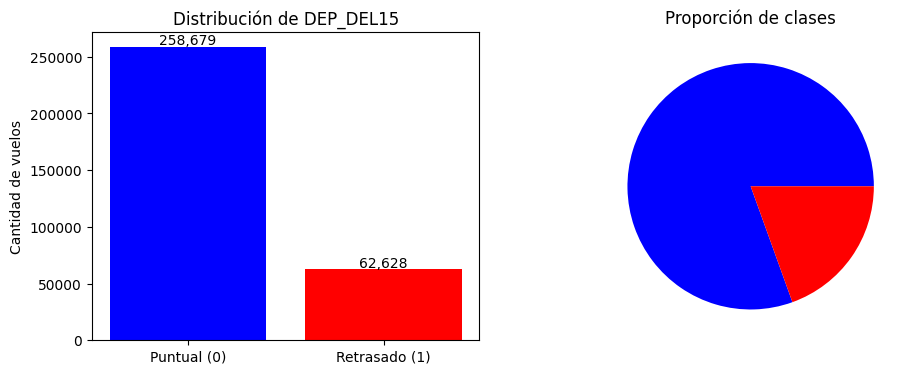

In [81]:
#analisis de la variable Y

# Convertir a entero (viene como float 0.0 / 1.0)
df['DEP_DEL15'] = df['DEP_DEL15'].astype(int)

conteo = df['DEP_DEL15'].value_counts()
porcentaje = df['DEP_DEL15'].value_counts(normalize=True) * 100

print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO')
print(f'  0 (vuelo puntual)    : {conteo[0]:,}  ({porcentaje[0]}%)')
print(f'  1 (retraso > 15 min) : {conteo[1]:,}  ({porcentaje[1]}%)')
print()

fig, axes = pyplot.subplots(1, 2, figsize=(11, 4))

# Gráfica de barras
axes[0].bar(['Puntual (0)', 'Retrasado (1)'],
            [conteo[0], conteo[1]],
            color=['blue', 'red'])
axes[0].set_ylabel('Cantidad de vuelos')
axes[0].set_title('Distribución de DEP_DEL15')

for i, v in enumerate([conteo[0], conteo[1]]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

# Gráfica circular
axes[1].pie([conteo[0], conteo[1]],
            colors=['blue', 'red'])
axes[1].set_title('Proporción de clases')

pyplot.show()

In [82]:
#valor numerico a las variables "Texto"

# Las columnas OP_CARRIER, ORIGIN, DEST y TAIL_NUM son texto
# No pueden usarse directamente en un modelo matemático
#
# Solución: Frequency Encoding
# Cada valor de texto se reemplaza por su frecuencia relativa
# en el dataset completo.
#
# Ejemplo:
#   OP_CARRIER = 'AA' aparece en el 18% de los vuelos → se convierte en 0.18
#   ORIGIN = 'ATL' aparece en el 9% de los vuelos    → se convierte en 0.09
#   TAIL_NUM = 'N123AA' aparece en el 0.02%          → se convierte en 0.0002
#
# ¿Por qué no One-Hot Encoding?
#   TAIL_NUM tiene 3,885 valores únicos → one-hot crearía 3,885 columnas nuevas.
#   Frequency encoding mantiene la información en 1 sola columna numérica.

cols_texto = ['OP_CARRIER', 'ORIGIN', 'DEST', 'TAIL_NUM']

for col in cols_texto:
    # Calcular la frecuencia relativa de cada categoría
    frecuencia = df[col].value_counts(normalize=True)

    # Crear nueva columna numérica
    df[col + '_enc'] = df[col].map(frecuencia)

print('Frequency encoding completado')


Frequency encoding completado


In [127]:
#seleccion de las columnas utiles para X

# Columnas a descartar del dataframe para construir X
drop_cols = ['YEAR', 'CLR',
             'OP_CARRIER', 'ORIGIN', 'DEST', 'TAIL_NUM',
             # reemplazadas por _enc
             'DEP_DEL15', 'ARR_DEL15', 'DEP_DELAY', 'ARR_DELAY']

df_num = df.drop(columns=drop_cols)

# Calcular correlación absoluta de cada columna con la variable objetivo
correlaciones = df_num.corrwith(df['DEP_DEL15']).abs().sort_values(ascending=False)
correlaciones = correlaciones.dropna()   # Eliminar columnas sin variación

print(f'  Total de columnas disponibles para X: {len(correlaciones)}')
print()

# Usar TODAS las columnas disponibles
cols_X = correlaciones.index.tolist()


N_COLS = len(cols_X)

print(f'total de columnas usadas para X: {N_COLS}')
print(f'columnas seleccionadas: {cols_X}')

  Total de columnas disponibles para X: 37

total de columnas usadas para X: 37
columnas seleccionadas: ['CRS_DEP_TIME', 'HOUR', 'CRS_ARR_TIME', 'HourlyRelativeHumidity', 'DISTANCE', 'HourlyDryBulbTemperature', 'BKN', 'ORIGIN_enc', 'DEST_enc', 'MONTH', 'Layer1 Height', 'OVC', 'HourlyWindSpeed', 'OP_CARRIER_enc', 'TS', 'Layer3 Height', 'IS_HOLIDAY', 'HourlyWindDirection', 'Layer2 Height', 'FG', 'FU', 'HZ', 'HourlyDewPointTemperature', 'FZ', 'FZRA', 'SCT', 'DZ', 'SN', 'HourlyPrecipitation', 'HourlyStationPressure', 'HourlyWindGustSpeed', 'DAY_OF_MONTH', 'HourlyVisibility', 'FEW', 'TAIL_NUM_enc', 'BR', 'RA']


In [129]:
#preparacion de X e Y

# Extraer todas las columnas seleccionadas como matriz X
X_full = df[cols_X].values

# Extraer la variable objetivo como vector y (valores 0 o 1)
y_full = df['DEP_DEL15'].values

m_total = y_full.size

print(f'  Dimensiones de X : {X_full.shape}  →  {m_total:,} muestras, {N_COLS} características')
print(f'  Dimensiones de y : {y_full.shape}  →  valores 0 o 1')
print()
print('Primeras 3 filas de X (truncadas):')
print(X_full[:3, :8])   # Mostrar solo las primeras 8 columnas
print()
print('Primeros 10 valores de y:', y_full[:10])

  Dimensiones de X : (321307, 37)  →  321,307 muestras, 37 características
  Dimensiones de y : (321307,)  →  valores 0 o 1

Primeras 3 filas de X (truncadas):
[[1.70000000e+03 0.00000000e+00 5.90000000e+01 8.90000000e+01
  2.67700000e+03 3.80000000e+01 1.00000000e+00 8.87002151e-03]
 [2.13500000e+03 0.00000000e+00 1.00000000e+01 8.90000000e+01
  1.10700000e+03 3.80000000e+01 1.00000000e+00 2.19727550e-02]
 [2.24500000e+03 1.00000000e+00 1.12000000e+02 8.60000000e+01
  1.66000000e+03 3.80000000e+01 1.00000000e+00 1.51817421e-02]]

Primeros 10 valores de y: [0 0 0 1 0 0 0 0 0 0]


In [130]:
# division del 80/20 entrenamiento/prueba

# Mezclar aleatoriamente todos los índices del dataset
indices = np.random.permutation(m_total)

# Punto de corte al 80%
corte = int(0.80 * m_total)

# Separar índices
idx_train = indices[:corte]    # 80% para entrenar
idx_test  = indices[corte:]    # 20% para probar

# Crear conjuntos de datos
X_train, y_train = X_full[idx_train], y_full[idx_train]
X_test,  y_test  = X_full[idx_test],  y_full[idx_test]

m_train = len(y_train)
m_test  = len(y_test)

print('DIVISION DE DATOS')
print(f'  Total           : {m_total:,} vuelos')
print(f'  Entrenamiento   : {m_train:,}  ({m_train/m_total*100}%)')
print(f'  Prueba          : {m_test:,}   ({m_test/m_total*100}%)')
print()
print('  Balance en TRAIN:')
print(f'    Clase 0: {(y_train==0).sum()}  ({(y_train==0).mean()*100}%)')
print(f'    Clase 1: {(y_train==1).sum()}   ({(y_train==1).mean()*100}%)')
print()
print('  Balance en TEST:')
print(f'    Clase 0: {(y_test==0).sum()}   ({(y_test==0).mean()*100}%)')
print(f'    Clase 1: {(y_test==1).sum()}   ({(y_test==1).mean()*100}%)')

DIVISION DE DATOS
  Total           : 321,307 vuelos
  Entrenamiento   : 257,045  (79.99981326270515%)
  Prueba          : 64,262   (20.00018673729486%)

  Balance en TRAIN:
    Clase 0: 206753  (80.43455426092707%)
    Clase 1: 50292   (19.565445739072924%)

  Balance en TEST:
    Clase 0: 51926   (80.80358532258568%)
    Clase 1: 12336   (19.196414677414335%)


---
## Normalización

Las 37 variables tienen escalas muy distintas: `CRS_DEP_TIME` va de 1 a 2359, `IS_HOLIDAY` es 0 o 1, `DISTANCE` llega a 2724. Sin normalizar, el descenso por gradiente converge muy lentamente o diverge.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

**Regla fundamental:** μ y σ se calculan **solo sobre train** y se aplican al test con los mismos valores. Nunca se recalculan sobre test.

In [131]:
#normalizacion

# Media y desviación estándar
mu    = np.mean(X_train, axis=0)
sigma = np.std(X_train,  axis=0)

# Evitar división por cero si alguna columna tiene desv. estándar = 0
sigma[sigma == 0] = 1

# Normalizar el conjunto de entrenamiento
X_train_norm = (X_train - mu) / sigma

# Normalizar el conjunto
X_test_norm  = (X_test  - mu) / sigma

# Agregar columna de 1s al inicio
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b  = np.concatenate([np.ones((m_test,  1)), X_test_norm],  axis=1)

print('Normalización completada')
print(f'  X_train_b : {X_train_b.shape}  (1 sesgo + {N_COLS} características)')
print(f'  X_test_b  : {X_test_b.shape}')
print()
print('Verificación post-normalización')
print(f'  Medias   (primeras 5): {X_train_norm.mean(axis=0)[:5].round(6)}')
print(f'  Std devs (primeras 5): {X_train_norm.std(axis=0)[:5].round(6)}')

Normalización completada
  X_train_b : (257045, 38)  (1 sesgo + 37 características)
  X_test_b  : (64262, 38)

Verificación post-normalización
  Medias   (primeras 5): [ 0.  0. -0.  0. -0.]
  Std devs (primeras 5): [1. 1. 1. 1. 1.]


---
## Funciones matemáticas del modelo logístico

### Función Sigmoide
$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \Rightarrow \quad \sigma(z) \in (0, 1)$$

### Función de Costo — Cross-Entropy (Log-Loss)
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

### Gradiente vectorizado
$$\nabla J(\theta) = \frac{1}{m} X^T \left( \sigma(X\theta) - y \right)$$

### Actualización del descenso por gradiente
$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

In [132]:
#funciones del modelo logistico

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def calcularCosto(theta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = -(1.0/m) * (np.dot(y, np.log(h)) + np.dot(1-y, np.log(1-h)))
    return J


def calcularGradiente(theta, X, y):
    m    = len(y)
    h    = sigmoid(np.dot(X, theta))
    grad = (1.0/m) * np.dot(X.T, (h - y))
    return grad


# Verificación con theta=0 — el costo debe ser exactamente log(2)
theta_test = np.zeros(X_train_b.shape[1])
J_inicial  = calcularCosto(theta_test, X_train_b, y_train)

print('VERIFICACIÓN DE FUNCIONES')
print(f'  Costo con theta=0 : {J_inicial}')
print(f'  Valor esperado    : {np.log(2)}')
print()
print(f'  sigmoid(  0) = {sigmoid(0):.4f}   debe ser similar 0.5')
print(f'  sigmoid( 10) = {sigmoid(10):.5f}  debe ser similar 1.0')
print(f'  sigmoid(-10) = {sigmoid(-10):.5f} debe ser similar 0.0')

VERIFICACIÓN DE FUNCIONES
  Costo con theta=0 : 0.6931471805599997
  Valor esperado    : 0.6931471805599453

  sigmoid(  0) = 0.5000   debe ser similar 0.5
  sigmoid( 10) = 0.99995  debe ser similar 1.0
  sigmoid(-10) = 0.00005 debe ser similar 0.0


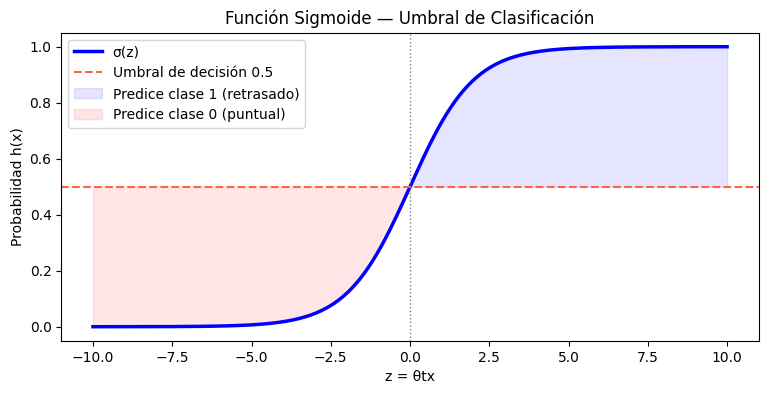

In [133]:
#visualizacion de sigmoide
z_vals = np.linspace(-10, 10, 300)

pyplot.figure(figsize=(9, 4))
pyplot.plot(z_vals, sigmoid(z_vals), lw=2.5, color='blue', label='σ(z)')
pyplot.axhline(0.5, color='tomato', lw=1.5, linestyle='--', label='Umbral de decisión 0.5')
pyplot.axvline(0.0, color='gray',   lw=1.0, linestyle=':')
pyplot.fill_between(z_vals, sigmoid(z_vals), 0.5,
                    where=sigmoid(z_vals) >= 0.5, alpha=0.1, color='blue',
                    label='Predice clase 1 (retrasado)')
pyplot.fill_between(z_vals, sigmoid(z_vals), 0.5,
                    where=sigmoid(z_vals) < 0.5, alpha=0.1, color='red',
                    label='Predice clase 0 (puntual)')
pyplot.xlabel('z = θtx')
pyplot.ylabel('Probabilidad h(x)')
pyplot.title('Función Sigmoide — Umbral de Clasificación')
pyplot.legend()
pyplot.show()

In [134]:
#descenso por gradiente

def descensoGradiente(X, y, theta, alpha, num_iters):
    J_history = []     # Historial de costo para graficar convergencia
    m = len(y)

    for i in range(num_iters):
        # predicciones actuales del modelo
        h = sigmoid(np.dot(X, theta))

        # calcular el gradiente con todos los ejemplos
        gradiente = (1.0/m) * np.dot(X.T, (h - y))

        # actualizar todos los parámetros simultáneamente
        theta = theta - alpha * gradiente

        # Guardar el costo de esta iteración
        J_history.append(calcularCosto(theta, X, y))

        if (i + 1) % 100 == 0:
            print(f'  Iter {i+1:>4}/{num_iters}  →  J = {J_history[-1]:.6f}')

    return theta, J_history


# Parámetros de entrenamiento
alpha_batch     = 0.3
num_iters_batch = 2000

# Inicializar theta en ceros: 1 sesgo + 37 características = 38 parámetros
theta_batch = np.zeros(X_train_b.shape[1])

print('ENTRENAMIENTO')
print(f'  Alpha       : {alpha_batch}')
print(f'  Iteraciones : {num_iters_batch}')
print(f'  Parámetros  : {len(theta_batch)}  (1 sesgo + {N_COLS} características)')
print(f'  Costo inicial J = {calcularCosto(theta_batch, X_train_b, y_train)}')
print()

theta_batch, J_hist_batch = descensoGradiente(
    X_train_b, y_train, theta_batch, alpha_batch, num_iters_batch
)

print()
print(f'  Costo final J = {J_hist_batch[-1]}')
print(f'  Theta (θ₀...θ₄): {theta_batch[:5].round(5)}')

ENTRENAMIENTO
  Alpha       : 0.3
  Iteraciones : 2000
  Parámetros  : 38  (1 sesgo + 37 características)
  Costo inicial J = 0.6931471805599997

  Iter  100/2000  →  J = 0.480344
  Iter  200/2000  →  J = 0.480178
  Iter  300/2000  →  J = 0.480134
  Iter  400/2000  →  J = 0.480120
  Iter  500/2000  →  J = 0.480115
  Iter  600/2000  →  J = 0.480112
  Iter  700/2000  →  J = 0.480111
  Iter  800/2000  →  J = 0.480110
  Iter  900/2000  →  J = 0.480109
  Iter 1000/2000  →  J = 0.480108
  Iter 1100/2000  →  J = 0.480107
  Iter 1200/2000  →  J = 0.480106
  Iter 1300/2000  →  J = 0.480104
  Iter 1400/2000  →  J = 0.480103
  Iter 1500/2000  →  J = 0.480102
  Iter 1600/2000  →  J = 0.480101
  Iter 1700/2000  →  J = 0.480100
  Iter 1800/2000  →  J = 0.480100
  Iter 1900/2000  →  J = 0.480099
  Iter 2000/2000  →  J = 0.480098

  Costo final J = 0.4800975403723314
  Theta (θ₀...θ₄): [-1.4725   0.28752  0.05169  0.08775 -0.06373]


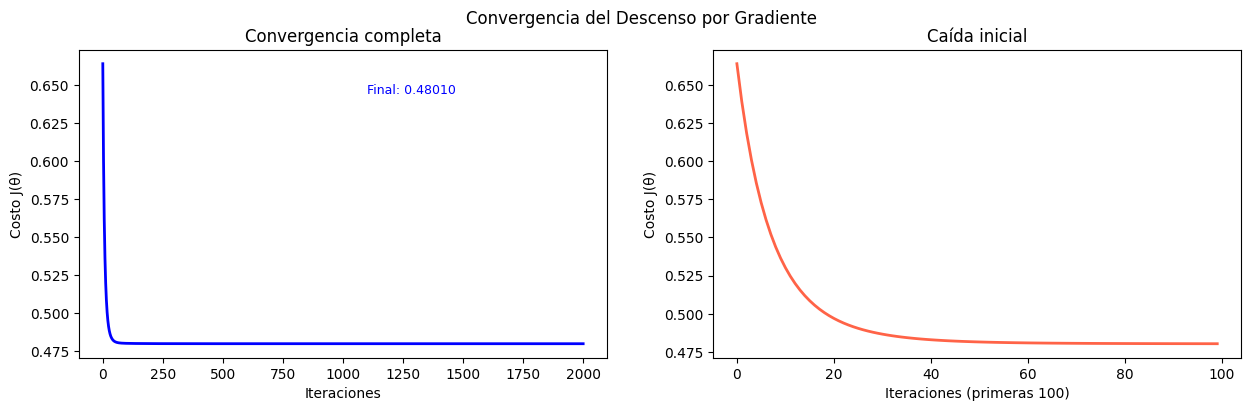

In [135]:
#grafica de costo

fig, axes = pyplot.subplots(1, 2, figsize=(15, 4))

#convergencia completa
axes[0].plot(np.arange(num_iters_batch), J_hist_batch, lw=2, color='blue')
axes[0].set_xlabel('Iteraciones')
axes[0].set_ylabel('Costo J(θ)')
axes[0].set_title('Convergencia completa')
axes[0].text(num_iters_batch*0.55, max(J_hist_batch)*0.97,
             f'Final: {J_hist_batch[-1]:.5f}', fontsize=9, color='blue')

#primeras 100 iteraciones
axes[1].plot(np.arange(100), J_hist_batch[:100], lw=2, color='tomato')
axes[1].set_xlabel('Iteraciones (primeras 100)')
axes[1].set_ylabel('Costo J(θ)')
axes[1].set_title('Caída inicial')

pyplot.suptitle('Convergencia del Descenso por Gradiente')
pyplot.show()

In [136]:
# predecir 5 valores

def predecir(theta, X):

    prob   = sigmoid(np.dot(X, theta))
    umbral = 0.6
    clases = (prob >= umbral).astype(int)
    return prob, clases


# Prueba rápida con 5 ejemplos del conjunto de train
prob_demo, clase_demo = predecir(theta_batch, X_train_b[:5])

print('VERIFICACIÓN DE predecir() — 5 ejemplos de entrenamiento ===')
print(f"  {'Prob. cruda':>12}  {'Umbral':>8}  {'Clase':>6}  {'Real':>6}")

for p, c, r in zip(prob_demo, clase_demo, y_train[:5]):
    simbolo = '>= 0.5' if p >= 0.5 else ' < 0.5'
    print(f'  {p:>12.4f}  {simbolo:>8}  {c:>6}  {int(r):>6}')

VERIFICACIÓN DE predecir() — 5 ejemplos de entrenamiento ===
   Prob. cruda    Umbral   Clase    Real
        0.2272     < 0.5       0       0
        0.1949     < 0.5       0       1
        0.2026     < 0.5       0       1
        0.1467     < 0.5       0       0
        0.2925     < 0.5       0       0


In [137]:
#evaluacion del entrenamiento
prob_train, pred_train = predecir(theta_batch, X_train_b)

precision_train = np.mean(pred_train == y_train) * 100

print(' EVALUACIÓN ENTRENAMIENTO (80%)')
print(f'  precision : {precision_train:.2f}%')

 EVALUACIÓN ENTRENAMIENTO (80%)
  precision : 80.44%


In [138]:
#evaluacion con el 20% de datos restantes

prob_test, pred_test = predecir(theta_batch, X_test_b)

precision_test = np.mean(pred_test == y_test) * 100

print('EVALUACIÓN PRUEBA (20% datos nunca vistos)')
print(f'precision : {precision_test}%')

EVALUACIÓN PRUEBA (20% datos nunca vistos)
precision : 80.80514145218014%


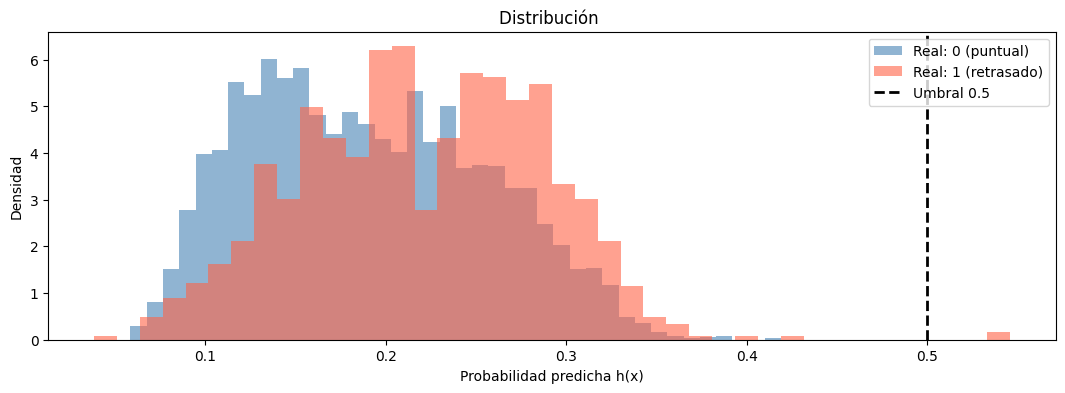

In [139]:
#grafica de evalucion del modelo

fig, axes = pyplot.subplots(1, 1, figsize=(13, 4))

# Distribución de probabilidades separada por clase real
muestra = np.random.choice(m_test, size=5000, replace=False)
prob_s  = prob_test[muestra]
y_s     = y_test[muestra]

axes.hist(prob_s[y_s == 0], bins=40, alpha=0.6, color='steelblue',
             label='Real: 0 (puntual)', density=True)
axes.hist(prob_s[y_s == 1], bins=40, alpha=0.6, color='tomato',
             label='Real: 1 (retrasado)', density=True)
axes.axvline(0.5, color='black', lw=2, linestyle='--', label='Umbral 0.5')
axes.set_xlabel('Probabilidad predicha h(x)')
axes.set_ylabel('Densidad')
axes.set_title('Distribución ')
axes.legend()
pyplot.show()

In [144]:
#parametros θ aprendidos
print('PARÁMETROS θ APRENDIDOS')
print(f'  θ₀ (sesgo/intercepto): {theta_batch[0]:.5f}')
print()
print('  θ por característica:')

# Obtener los nombres de las características correspondientes a theta_batch[1:]
feature_names = cols_X

# Crear un DataFrame temporal para ordenar las características por el valor absoluto de sus thetas
coef_df = pd.DataFrame({
    'Caracteristica': feature_names,
    'Theta': theta_batch[1:]
})

# Ordenar por el valor absoluto de Theta y seleccionar las 20 principales
top20 = coef_df.reindex(coef_df['Theta'].abs().sort_values(ascending=False).index)['Caracteristica'].head(20).tolist()

print(f"  {'#':>3}  {'Característica':<35}  {'θ':>10}  Impacto")

for i, (col, th) in enumerate(zip(top20, theta_batch[1:])):
   corresponding_theta = coef_df[coef_df['Caracteristica'] == col]['Theta'].iloc[0]
   impacto = 'aumenta retraso' if corresponding_theta > 0 else 'reduce retraso'
   print(f"  {i+1:>3}  {col:<35}  {corresponding_theta:>+10.5f}  {impacto}")
print()
print('Interpretación: θ positivo → al crecer esa variable, aumenta P(retraso)')
print('               θ negativo → al crecer esa variable, disminuye P(retraso)')

PARÁMETROS θ APRENDIDOS
  θ₀ (sesgo/intercepto): -1.47250

  θ por característica:
    #  Característica                                θ  Impacto
    1  CRS_DEP_TIME                           +0.28752  aumenta retraso
    2  HourlyVisibility                       -0.13335  reduce retraso
    3  OP_CARRIER_enc                         +0.11608  aumenta retraso
    4  ORIGIN_enc                             +0.10203  aumenta retraso
    5  TAIL_NUM_enc                           -0.09570  reduce retraso
    6  MONTH                                  -0.09034  reduce retraso
    7  CRS_ARR_TIME                           +0.08775  aumenta retraso
    8  DISTANCE                               +0.06638  aumenta retraso
    9  HourlyRelativeHumidity                 -0.06373  reduce retraso
   10  HourlyWindSpeed                        +0.05845  aumenta retraso
   11  HourlyDryBulbTemperature               +0.05538  aumenta retraso
   12  DEST_enc                               +0.05333  aumenta r

In [147]:

# CELDA 20 — Predicción manual (ingresa valores de un vuelo)
# Los valores deben seguir el orden exacto de cols_X.

# Rangos de referencia:
#
#  #  Variable                    Min      Media     Max
#  1  CRS_DEP_TIME                1        1326      2359   (hora salida HHMM)
#  2  HOUR                        0        13.96     23
#  3  CRS_ARR_TIME                1        1506      2359   (hora llegada HHMM)
#  4  HourlyRelativeHumidity      14       68.1      100    (%)
#  5  DISTANCE                    93       1262      2724   (millas)
#  6  HourlyDryBulbTemperature    -14      55.5      107    (°F)
#  7  BKN                         0        0.17      1      (0/1 nublado parcial)
#  8  ORIGIN_enc                  0.0005   0.0107    0.093  (frecuencia aeropuerto origen)
#  9  DEST_enc                    0.0005   0.0107    0.093  (frecuencia aeropuerto destino)
# 10  MONTH                       1        6.7       12
# 11  Layer1 Height               0        17870     100000
# 12  OVC                         0        0.13      1      (0/1 nublado total)
# 13  HourlyWindSpeed             0        8.7       76     (mph)
# 14  OP_CARRIER_enc              0.005    0.09      0.21   (frecuencia aerolínea)
# 15  TS                          0        0.01      1      (0/1 tormenta)
# 16  Layer3 Height               0        26940     100000
# 17  IS_HOLIDAY                  0        0.03      1      (0/1 festivo)
# 18  HourlyWindDirection         0        196.6     360    (grados)
# 19  Layer2 Height               0        22260     100000
# 20  FG                          0        0.01      1      (0/1 niebla)
# 21  FU                          0        0.002     1      (0/1 humo)
# 22  HZ                          0        0.002     1      (0/1 neblina)
# 23  HourlyDewPointTemperature   -23      43.5      79     (°F)
# 24  FZ                          0        0.001     1      (0/1 helada)
# 25  FZRA                        0        0.001     1      (0/1 lluvia helada)
# 26  SCT                         0        0.17      1      (0/1 nubes dispersas)
# 27  DZ                          0        0.001     1      (0/1 llovizna)
# 28  SN                          0        0.004     1      (0/1 nieve)
# 29  HourlyPrecipitation         0        0.006     1.5
# 30  HourlyStationPressure       28.5     29.9      31
# 31  HourlyWindGustSpeed         0        4.2       71     (mph)
# 32  DAY_OF_MONTH                1        15.7      31
# 33  HourlyVisibility            0        7.5       10
# 34  FEW                         0        0.17      1      (0/1 pocas nubes)
# 35  TAIL_NUM_enc                0.0001   0.00026   0.006  (frecuencia avión)
# 36  BR                          0        0.006     1      (0/1 bruma)
# 37  RA                          0        0.003     1      (0/1 lluvia)

vuelo_manual = np.array([
    1800,    #  1 CRS_DEP_TIME
    18,      #  2 HOUR
    2100,    #  3 CRS_ARR_TIME
    75.0,    #  4 HourlyRelativeHumidity
    1500.0,  #  5 DISTANCE
    62.0,    #  6 HourlyDryBulbTemperature
    1,       #  7 BKN
    0.0107,  #  8 ORIGIN_enc
    0.0107,  #  9 DEST_enc
    7,       # 10 MONTH
    15000,   # 11 Layer1 Height
    0,       # 12 OVC
    15.0,    # 13 HourlyWindSpeed
    0.09,    # 14 OP_CARRIER_enc
    0,       # 15 TS
    20000,   # 16 Layer3 Height
    0,       # 17 IS_HOLIDAY
    180.0,   # 18 HourlyWindDirection
    17000,   # 19 Layer2 Height
    0,       # 20 FG
    0,       # 21 FU
    0,       # 22 HZ
    50.0,    # 23 HourlyDewPointTemperature
    0,       # 24 FZ
    0,       # 25 FZRA
    0,       # 26 SCT
    0,       # 27 DZ
    0,       # 28 SN
    0.0,     # 29 HourlyPrecipitation
    29.92,   # 30 HourlyStationPressure
    0.0,     # 31 HourlyWindGustSpeed
    15,      # 32 DAY_OF_MONTH
    10.0,    # 33 HourlyVisibility
    0,       # 34 FEW
    0.00026, # 35 TAIL_NUM_enc
    0,       # 36 BR
    0        # 37 RA
])

# Normalizar usando mu y sigma calculados durante el entrenamiento
vuelo_norm  = (vuelo_manual - mu) / sigma
vuelo_input = np.concatenate([[1], vuelo_norm])

# Predecir probabilidad y clase
prob_manual  = sigmoid(np.dot(vuelo_input, theta_batch))
clase_manual = int(np.round(prob_manual))

print('=' * 50)
print('   PREDICCIÓN PARA EL VUELO INGRESADO')
print('=' * 50)
print()
print(f'  Probabilidad de retraso  : {prob_manual:.4f}')
print(f'  Umbral de decisión       : 0.5000')
print(f'  Clase predicha           : {clase_manual}')
print()
if clase_manual == 1:
    print(f'  RESULTADO: {prob_manual*100:.2f}% de probabilidad de retraso')
    print(f'             → VUELO RETRASADO (clase 1)')
else:
    print(f'  RESULTADO: {prob_manual*100:.2f}% de probabilidad de retraso')
    print(f'             → VUELO PUNTUAL (clase 0)')
print('=' * 50)

   PREDICCIÓN PARA EL VUELO INGRESADO

  Probabilidad de retraso  : 0.2320
  Umbral de decisión       : 0.5000
  Clase predicha           : 0

  RESULTADO: 23.20% de probabilidad de retraso
             → VUELO PUNTUAL (clase 0)
